# Testing Data Retrieval and Database Building from WQP
Using WQP's webservice APIs

Good data, medium density, except no phosphorus.

In [1]:
# %pip -q install pandas

In [2]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.waterqualitydata.us/data/Result/search"
bbox = "-83.10,39.90,-82.90,40.05"

params = [
    # ("countrycode", "LE"),
    ("bBox", bbox),
    ("dataProfile", "resultPhysChem"),
    ("providers", "NWIS"),
    ("providers", "STORET"),
    ("mimeType", "csv"),
    ("zip", "no"),
    ("startDateLo", "01-01-2012"),
    ("startDateHi", "12-31-2022"),
]

r = requests.get(url, params=params, timeout=180)
print("STATUS:", r.status_code)
print("URL:", r.url)
print("Warning:", r.headers.get("Warning"))
print("BODY preview:", r.text[:300])

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))
df.head()


STATUS: 200
URL: https://www.waterqualitydata.us/data/Result/search?bBox=-83.10%2C39.90%2C-82.90%2C40.05&dataProfile=resultPhysChem&providers=NWIS&providers=STORET&mimeType=csv&zip=no&startDateLo=01-01-2012&startDateHi=12-31-2022
BODY preview: OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,ActivityEndTime/Time,ActivityEndTime/TimeZoneCode,ActivityRelativeDepthName,Activit


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,...,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,LabSamplePreparationUrl,LastUpdated,ProviderName
0,21OHDGW_WQX,Division of Drinking and Ground Water (Ohio),21OHDGW_WQX-GW12279,Sample-Routine,Water,Groundwater,2014-04-01,NaN,NaN,NaN,...,DES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-03-10T08:29:58,STORET
1,21OHDGW_WQX,Division of Drinking and Ground Water (Ohio),21OHDGW_WQX-GW12257,Sample-Routine,Water,Groundwater,2014-04-01,NaN,NaN,NaN,...,NaN,NaN,NaN,https://www.waterqualitydata.us/data/providers...,Practical Quantitation Limit,0.5,ug/L,NaN,2016-03-10T08:32:36,STORET
2,21OHDGW_WQX,Division of Drinking and Ground Water (Ohio),21OHDGW_WQX-GWFM12565,Field Msr/Obs,Water,Groundwater,2014-10-14,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-03-10T08:31:33,STORET
3,21OHDGW_WQX,Division of Drinking and Ground Water (Ohio),21OHDGW_WQX-GW12257,Sample-Routine,Water,Groundwater,2014-04-01,NaN,NaN,NaN,...,NaN,NaN,NaN,https://www.waterqualitydata.us/data/providers...,Practical Quantitation Limit,0.5,ug/L,NaN,2016-03-10T08:32:35,STORET
4,21OHIO_WQX,Division of Surface water (Ohio),21OHIO_WQX-C38972,Sample-Routine,Water,NaN,2014-05-06,NaN,NaN,NaN,...,DES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-02-09T12:18:06,STORET


In [3]:
df.shape

(2001, 81)

Note: Chicago's bounding box seems to have very little data.

## Core Columns for Trend Analysis

### Time Axis (Mandatory)
- `ActivityStartDate`
- `ActivityStartTime/Time`
- `ActivityEndDate`
- `ActivityEndTime/Time`

### Location Axis (Mandatory)
- `MonitoringLocationIdentifier`

### Location Context
- `ActivityDepthHeightMeasure/MeasureValue`
- `ActivityMediaName`

### Measurement Axis (Mandatory)
- `CharacteristicName`
- `ResultMeasureValue`
- `ResultMeasure/MeasureUnitCode`

---

## Quality Control Columns
- `ResultStatusIdentifier`
- `MeasureQualifierCode`
- `DetectionQuantitationLimitMeasure/MeasureValue`
- `ResultDetectionConditionText`

---

## Optional but Useful Columns
- `ProjectIdentifier`
- `ResultAnalyticalMethod/MethodName`
- `DataProvider`
- `ActivityDepthHeightMeasure/MeasureUnitCode`


Other potential columns:
- `ResultSampleFractionText`
- `ResultStatusIdentifier`
- `ResultAnalyticalMethod/MethodIdentifier`
- `ResultAnalyticalMethod/MethodIdentifierContext`
- `ResultAnalyticalMethod/MethodName`

- `AnalysisStartDate`
- `LastUpdated`

In [4]:
# filter only necessary columns
columns_to_keep = [
    "ActivityStartDate",
    "ActivityStartTime/Time",
    "ActivityEndDate",
    "ActivityEndTime/Time",
    "MonitoringLocationIdentifier",
    "ActivityDepthHeightMeasure/MeasureValue",
    "ActivityMediaName",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode",
    "ResultStatusIdentifier",
    "MeasureQualifierCode",
    "DetectionQuantitationLimitMeasure/MeasureValue",
    "ResultDetectionConditionText",
    "ProjectIdentifier",
    "ResultAnalyticalMethod/MethodName",
    "ProviderName",
    "ActivityDepthHeightMeasure/MeasureUnitCode",
]

df_target = df[columns_to_keep]
df_target.head(10), df_target.shape


(  ActivityStartDate ActivityStartTime/Time ActivityEndDate  \
 0        2014-04-01                    NaN             NaN   
 1        2014-04-01                    NaN             NaN   
 2        2014-10-14                    NaN             NaN   
 3        2014-04-01                    NaN             NaN   
 4        2014-05-06                    NaN             NaN   
 5        2014-04-01                    NaN             NaN   
 6        2014-04-01                    NaN             NaN   
 7        2014-10-14                    NaN             NaN   
 8        2014-10-14                    NaN             NaN   
 9        2014-04-01                    NaN             NaN   
 
   ActivityEndTime/Time MonitoringLocationIdentifier  \
 0                  NaN       21OHDGW_WQX-39FRA00404   
 1                  NaN       21OHDGW_WQX-39FRA00404   
 2                  NaN       21OHDGW_WQX-39FRA00404   
 3                  NaN       21OHDGW_WQX-39FRA00404   
 4                  NaN  

In [5]:
# %pip install matplotlib

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# visualizations for multiple characteristics
def plot_wqp_characteristic_trends(
    df: pd.DataFrame,
    characteristics,
    date_col: str = "ActivityStartDate",
    char_col: str = "CharacteristicName",
    value_col: str = "ResultMeasureValue",
    unit_col: str = "ResultMeasure/MeasureUnitCode",
    only_accepted: bool = False,
    status_col: str = "ResultStatusIdentifier",
    choose_unit: str = "most_common",   # "most_common" or a specific unit string
    showfliers: bool = False,
    point_size: int = 8
):
    """
    For each characteristic in `characteristics`, plots:
      A) raw scatter over time
      B) monthly mean trend
      C) monthly boxplots (distribution by month)

    Notes:
      - Drops rows with missing date/characteristic/value
      - Coerces date/value types
      - Optionally filters to accepted results
      - If multiple units exist, can pick the most common unit to avoid mixing
    """
    # Normalize characteristics input
    if isinstance(characteristics, str):
        characteristics = [characteristics]

    data = df.copy()

    # Basic cleaning
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    if only_accepted and status_col in data.columns:
        data = data[data[status_col].astype(str).str.lower().eq("accepted")]

    # Drop rows missing critical fields
    data = data.dropna(subset=[date_col, char_col, value_col])

    print("num rows after cleaning:", len(data))
    print("unique characteristics:", data[char_col].nunique())

    for char in characteristics:
        dchar = data[data[char_col] == char].copy()

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after filtering).")
            continue

        # Unit handling
        unit = None
        if unit_col in dchar.columns:
            if choose_unit == "most_common":
                unit = dchar[unit_col].dropna().value_counts().index[0] if dchar[unit_col].notna().any() else None
                if unit is not None:
                    dchar = dchar[dchar[unit_col] == unit]
            else: 
                unit = choose_unit
                dchar = dchar[dchar[unit_col] == unit]

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after unit filter).")
            continue

        print("Plotting characteristic:", char, "| unit:", unit)

        # ---- Plot A: raw time series (scatter) ----
        plt.figure(figsize=(4, 3))
        plt.scatter(dchar[date_col], dchar[value_col], s=point_size)
        plt.xlabel(date_col)
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Raw results over time: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot B: monthly mean trend ----
        monthly = (
            dchar.set_index(date_col)[value_col]
                .resample("MS")
                .mean()
                .dropna()
        )

        plt.figure(figsize=(4, 3))
        plt.plot(monthly.index, monthly.values)
        plt.xlabel("Month")
        plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly mean trend: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot C: monthly boxplots ----
        dchar["Month"] = dchar[date_col].dt.month
        months = list(range(1, 13))

        box_data = [
            dchar.loc[dchar["Month"] == m, value_col].dropna().values
            for m in months
        ]

        plt.figure(figsize=(4, 3))
        plt.boxplot(box_data, labels=months, showfliers=showfliers)
        plt.xlabel("Month")
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly distribution: {char}")
        plt.tight_layout()
        plt.show()


num rows after cleaning: 1559
unique characteristics: 55
Skipping 'Temperature, sample' (no rows after filtering).
Plotting characteristic: Chloride | unit: mg/L


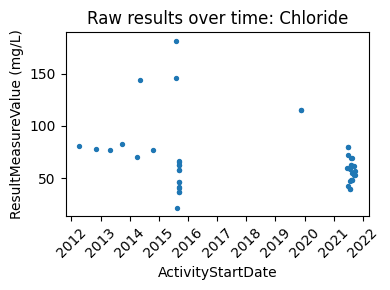

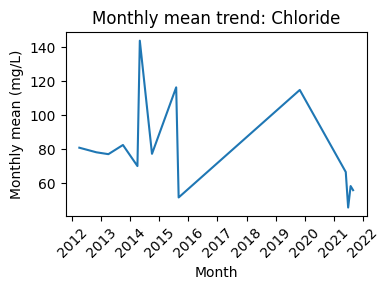

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


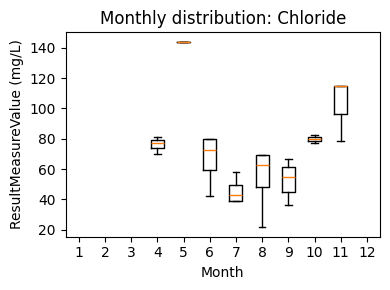

Plotting characteristic: Specific conductance | unit: umho/cm


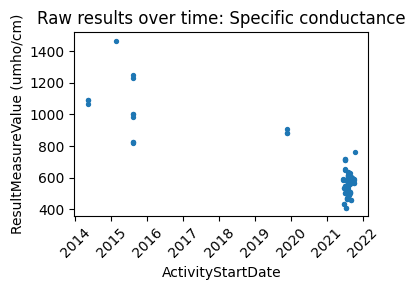

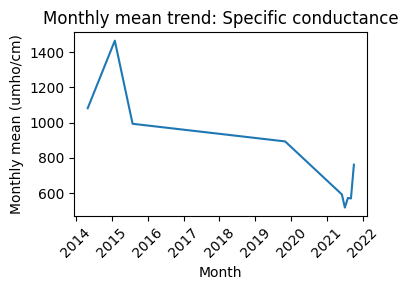

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


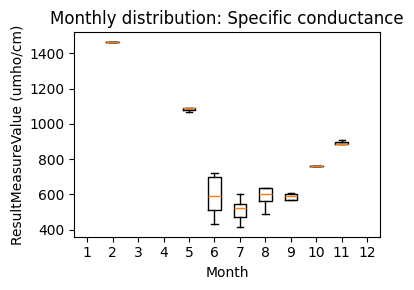

Skipping 'Flow' (no rows after filtering).
Plotting characteristic: Organic carbon | unit: mg/L


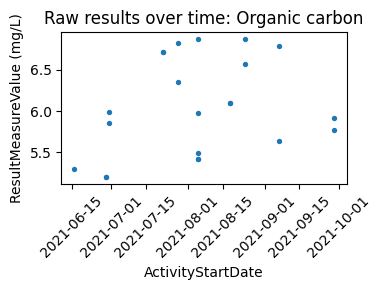

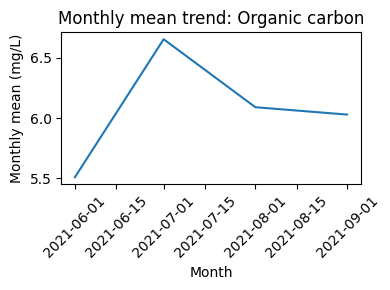

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


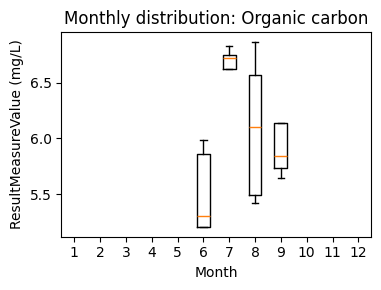

Plotting characteristic: pH | unit: None


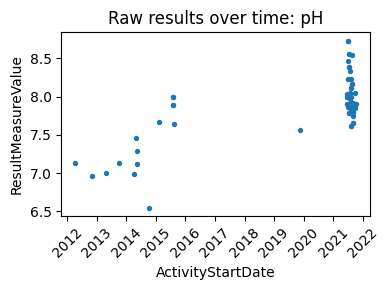

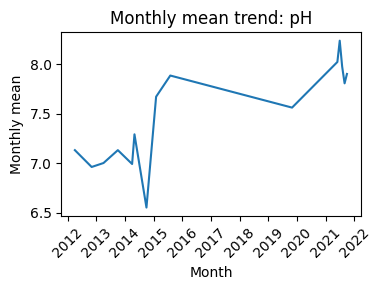

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


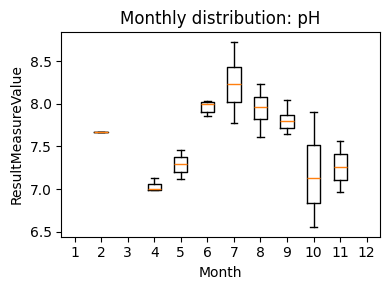

Plotting characteristic: Alkalinity, total | unit: mg/L


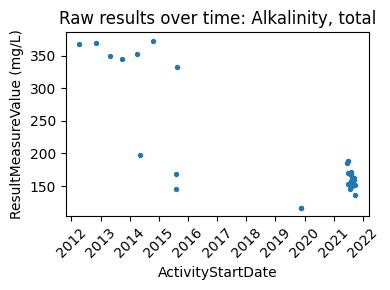

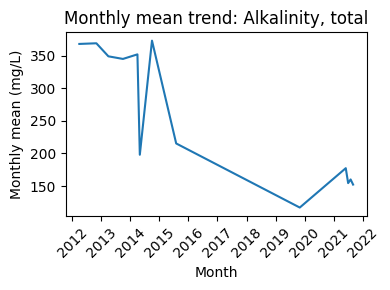

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


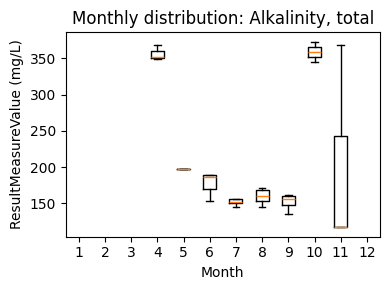

Skipping 'Depth, Secchi disk depth' (no rows after filtering).
Skipping 'Oxygen' (no rows after filtering).
Plotting characteristic: Total dissolved solids | unit: mg/L


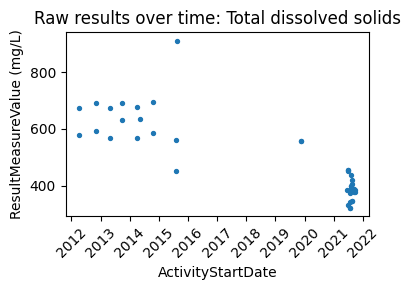

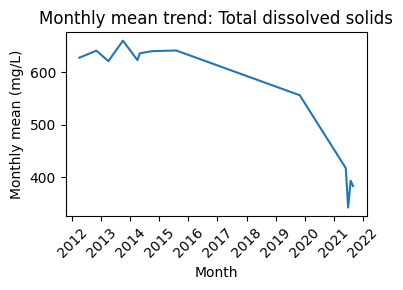

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


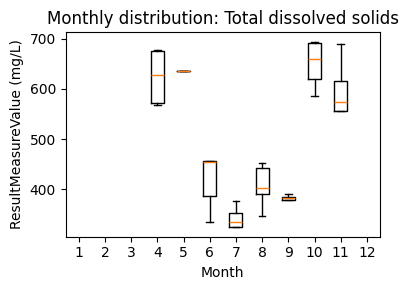

Skipping 'Nitrogen' (no rows after filtering).
Plotting characteristic: Phosphorus | unit: mg/L


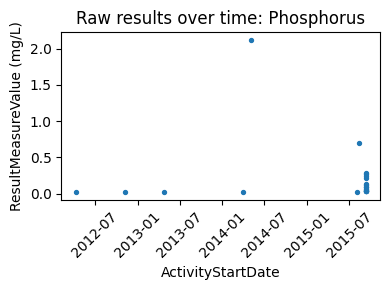

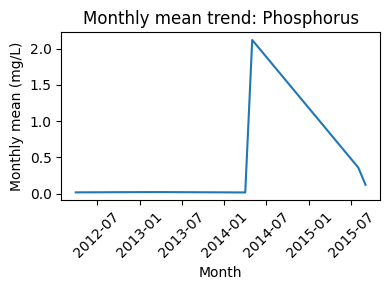

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


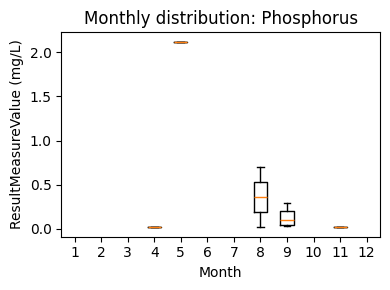

Skipping 'Chlorophyll a' (no rows after filtering).
Skipping 'Reservoir volume' (no rows after filtering).
Plotting characteristic: Total suspended solids | unit: mg/L


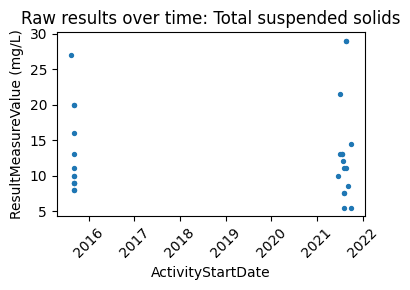

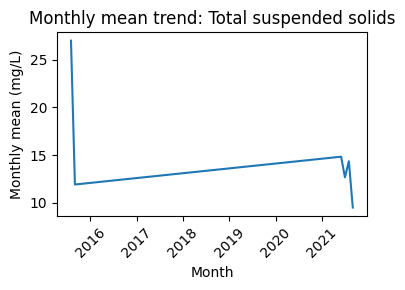

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


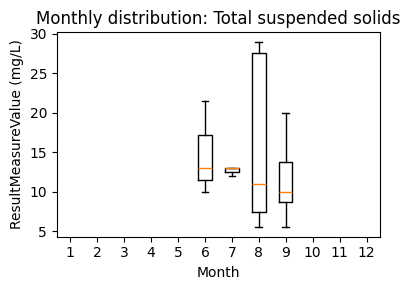

Plotting characteristic: Escherichia coli | unit: #/100mL


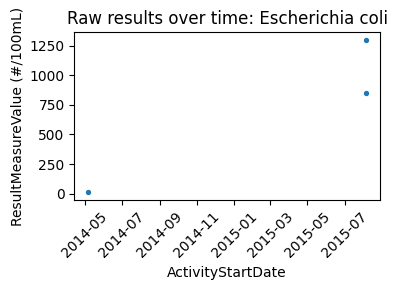

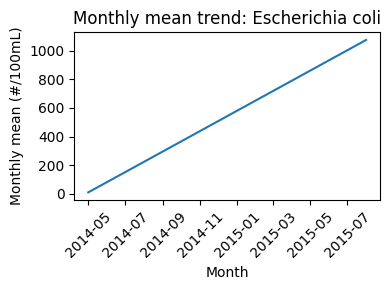

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


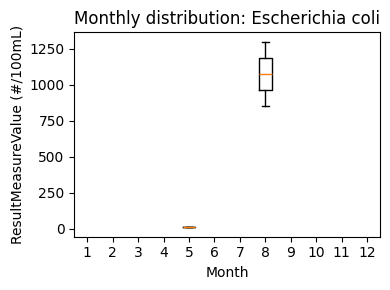

Skipping 'Hardness, magnesium' (no rows after filtering).
Plotting characteristic: Orthophosphate | unit: mg/L


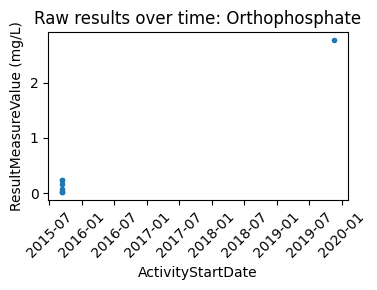

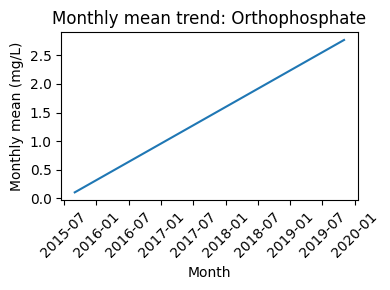

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


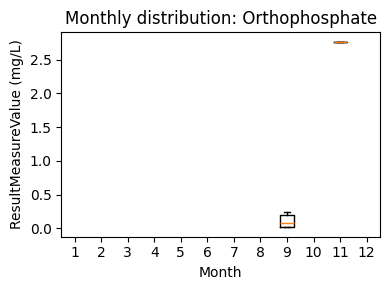

Skipping 'Precipitation' (no rows after filtering).
Plotting characteristic: Sulfate | unit: mg/L


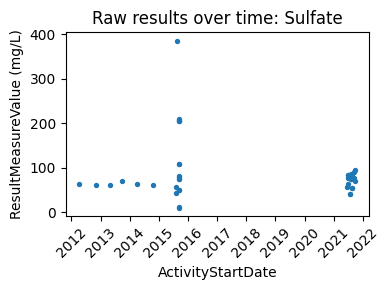

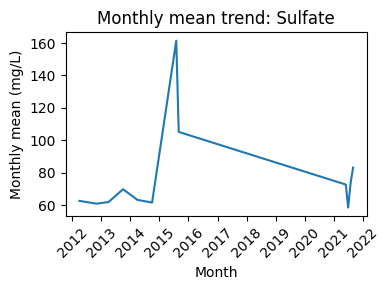

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


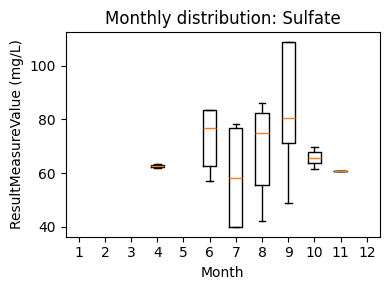

Plotting characteristic: Inorganic nitrogen (nitrate and nitrite) ***retired***use Nitrate + Nitrite | unit: mg/L


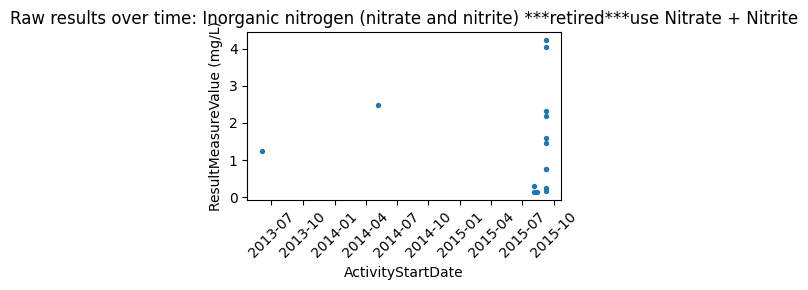

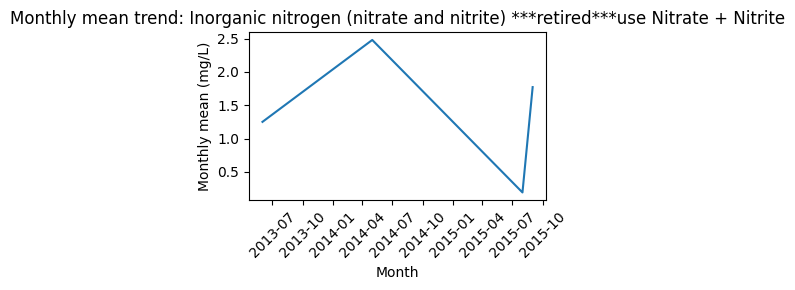

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


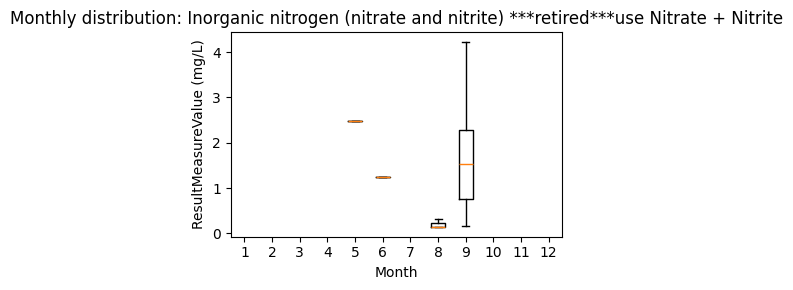

Plotting characteristic: Pheophytin a | unit: ug/L


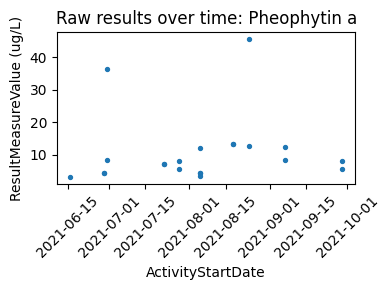

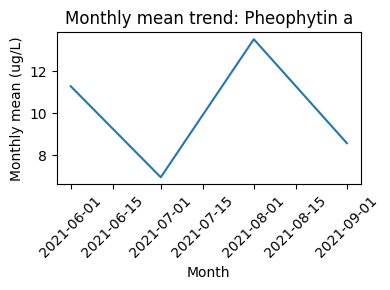

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


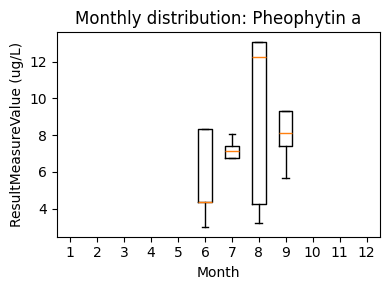

Skipping 'Nitrate' (no rows after filtering).
Skipping 'Depth' (no rows after filtering).
Skipping 'Total volatile solids' (no rows after filtering).
Plotting characteristic: Iron | unit: ug/L


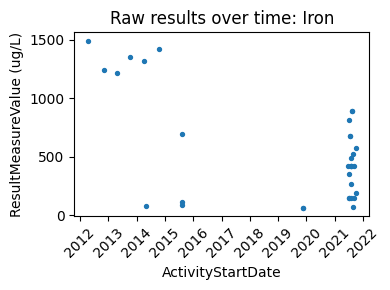

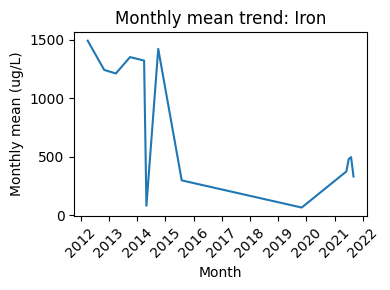

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


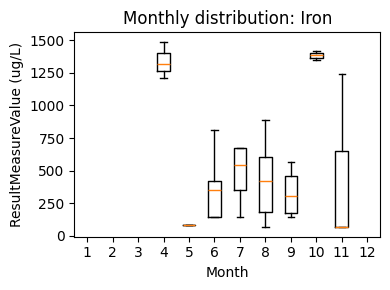

Skipping 'Ammonia-nitrogen' (no rows after filtering).
Plotting characteristic: Nitrite | unit: mg/L


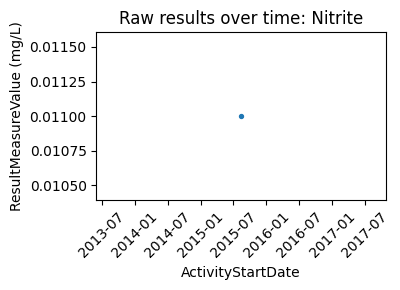

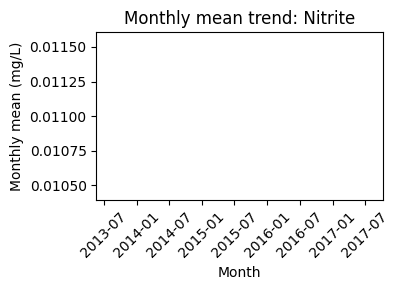

C:\Users\kcui2\AppData\Local\Temp\ipykernel_37800\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


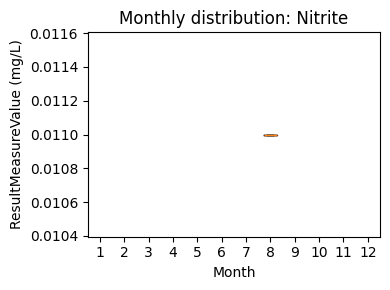

In [7]:
chars = [
    "Temperature, sample",
    "Chloride",
    "Specific conductance",
    "Flow",
    "Organic carbon",
    "pH",
    "Alkalinity, total",
    "Depth, Secchi disk depth",
    "Oxygen",
    "Total dissolved solids",
    "Nitrogen",
    "Phosphorus",
    "Chlorophyll a",
    "Reservoir volume",
    "Total suspended solids",
    "Escherichia coli",
    "Hardness, magnesium",
    "Orthophosphate",
    "Precipitation",
    "Sulfate",
    "Inorganic nitrogen (nitrate and nitrite) ***retired***use Nitrate + Nitrite",
    "Pheophytin a",
    "Nitrate",
    "Depth",
    "Total volatile solids",
    "Iron",
    "Ammonia-nitrogen",
    "Nitrite"
]
plot_wqp_characteristic_trends(df_target, chars)


In [8]:
import pandas as pd
import numpy as np

def classify_selected_characteristics(df):

    df["ActivityStartDate"] = pd.to_datetime(df["ActivityStartDate"])
    df = df[df["CharacteristicName"].isin(chars)]

    results = []

    for char, g in df.groupby("CharacteristicName"):

        g = g.sort_values("ActivityStartDate")
        g["month"] = g["ActivityStartDate"].dt.to_period("M")

        counts = g.groupby("month").size()

        start = counts.index.min()
        end = counts.index.max()

        full_range = pd.period_range(start=start, end=end, freq="M")
        counts = counts.reindex(full_range, fill_value=0)

        months_with_data = (counts > 0).sum()
        total_months = len(counts)
        coverage = months_with_data / total_months

        # longest gap
        longest_gap = 0
        gap = 0
        for v in counts:
            if v == 0:
                gap += 1
                longest_gap = max(longest_gap, gap)
            else:
                gap = 0

        obs = len(g)

        if obs == 0:
            label = "Bad (no data)"
        elif coverage > 0.75 and longest_gap <= 2:
            label = "Good"
        elif coverage > 0.40:
            label = "Okay"
        else:
            label = "Bad"

        results.append({
            "Characteristic": char,
            "Observations": obs,
            "Coverage": round(coverage,2),
            "LongestGapMonths": longest_gap,
            "Label": label
        })

    return pd.DataFrame(results)


summary = classify_selected_characteristics(df)
summary.sort_values("Label")

,Characteristic,Observations,Coverage,LongestGapMonths,Label
0,"Alkalinity, total",34,0.11,50,Bad
1,Chloride,50,0.12,49,Bad
2,Escherichia coli,3,0.12,14,Bad
3,Inorganic nitrogen (nitrate and nitrite) ***re...,27,0.24,9,Bad
4,Iron,34,0.11,50,Bad
7,Orthophosphate,18,0.04,49,Bad
9,Phosphorus,26,0.21,9,Bad
10,Specific conductance,94,0.13,50,Bad
11,Sulfate,47,0.11,68,Bad
12,Total dissolved solids,40,0.11,50,Bad
